# Datasets
- Used the MIMIC 3 Dataset
- Used uae_hospital_diabetes_dataset_with_region_area
    - https://www.kaggle.com/datasets/walidbarghout/uae-hospital-diabetes-dataset-with-region-area?resource=download



# The Problem
- MIMIC 3 Diabetes Classification
- uae_hospital_diabestes_datasets_with_region_area Diabetes Classification

### MIMIC III Binary Diabetes Classification

In [3]:
### Load Packages
import pandas as pd
import numpy as np
import os
import sys

In [2]:
### Load Data

# Load the data from the MIMIC-III database from csv.gz files
patients = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/PATIENTS.csv.gz')
admissions = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/ADMISSIONS.csv.gz')
diagnoses_icd = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/DIAGNOSES_ICD.csv.gz')
d_icd_diagnoses = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/D_ICD_DIAGNOSES.csv.gz')
prescriptions = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/PRESCRIPTIONS.csv.gz')
procedures_icd = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/PROCEDURES_ICD.csv.gz')
noteevents = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/NOTEEVENTS.csv.gz')
labevents = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/LABEVENTS.csv.gz')

/tmp/ipykernel_1288728/1864227284.py:8: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  prescriptions = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/PRESCRIPTIONS.csv.gz')
/tmp/ipykernel_1288728/1864227284.py:10: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  noteevents = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 2: MIMIC Visualization/mimic-iii-clinical-database-1.4/NOTEEVENTS.csv.gz')


Identifying diabetic patients...
Found 10318 diabetic patients out of 46520 total

Extracting demographic features...
Demographic data extracted for 46520 patients

Extracting medication features...


/tmp/ipykernel_1288728/607627218.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demographics['GENDER'] = demographics['GENDER'].map({'M': 1, 'F': 0})


Medication data extracted for 46520 patients

Extracting lab features...


/tmp/ipykernel_1288728/607627218.py:156: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  glucose_stats = glucose_labs.groupby('SUBJECT_ID').apply(get_lab_stats).reset_index()
/tmp/ipykernel_1288728/607627218.py:162: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hba1c_stats = hba1c_labs.groupby('SUBJECT_ID').apply(get_lab_stats).reset_index()
/tmp/ipykernel_1288728/607627218.py:168: DeprecationWarning: DataFra

Lab data extracted for 46520 patients

Creating final dataset...

Final dataset shape: (46520, 18)
Diabetic patients in final dataset: 10318 (22.18%)

Sample of the final dataset:
   SUBJECT_ID  GENDER  ANCHOR_AGE  HAS_DIABETES  INSULIN_PRESCRIBED  \
0         249       0          74             1                   1   
1         250       0          24             0                   1   
2         251       1          20             0                   0   
3         252       1          55             0                   1   
4         253       0          85             0                   0   

   ORAL_DIABETES_MED  GLUCOSE_MEAN  GLUCOSE_MAX  GLUCOSE_MIN  GLUCOSE_COUNT  \
0                  0    136.746269        249.0         61.0           67.0   
1                  0    110.843478        276.0         48.0          115.0   
2                  0    101.000000        107.0         92.0            4.0   
3                  0    111.236842        141.0         85.0           38.0  

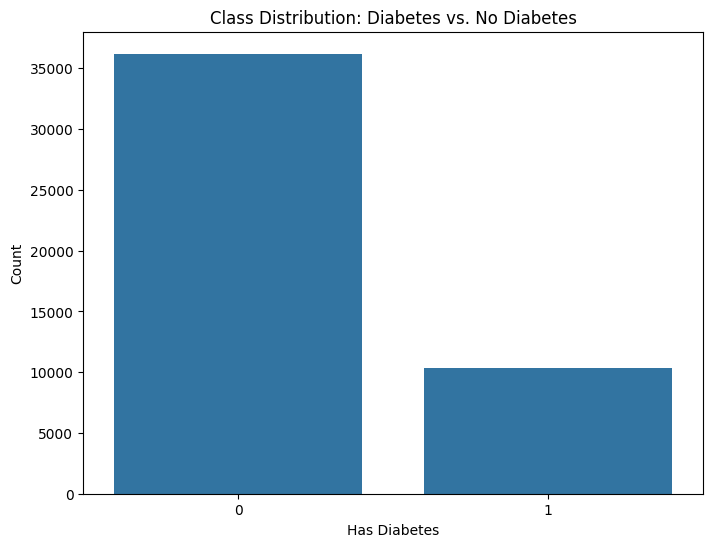


Preprocessed data saved to 'diabetes_classifier_data.csv'


In [5]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Identify diabetic patients using ICD-9 codes
def identify_diabetic_patients(diagnoses_icd, d_icd_diagnoses):
    # Get diabetes-related ICD-9 codes (250.xx)
    diabetes_codes = d_icd_diagnoses[d_icd_diagnoses['ICD9_CODE'].str.startswith('250', na=False)]
    
    # Get all patients with diabetes diagnoses
    diabetes_diagnoses = diagnoses_icd[diagnoses_icd['ICD9_CODE'].isin(diabetes_codes['ICD9_CODE'])]
    
    # Create a dataframe of patient IDs with diabetes
    diabetic_patients = pd.DataFrame({'SUBJECT_ID': diabetes_diagnoses['SUBJECT_ID'].unique(), 
                                      'HAS_DIABETES': 1})
    
    # Get all unique patient IDs
    all_patient_ids = diagnoses_icd['SUBJECT_ID'].unique()
    
    # Create a dataframe with all patients
    all_patients_df = pd.DataFrame({'SUBJECT_ID': all_patient_ids})
    
    # Merge to get binary label for all patients
    patient_diabetes_status = all_patients_df.merge(diabetic_patients, on='SUBJECT_ID', how='left')
    patient_diabetes_status['HAS_DIABETES'] = patient_diabetes_status['HAS_DIABETES'].fillna(0).astype(int)
    
    return patient_diabetes_status

# Step 2: Extract demographic features - FIXED to handle date issues
def extract_demographics(patients, admissions, patient_diabetes_status):
    # Get basic demographics
    demographics = patients[['SUBJECT_ID', 'GENDER']]
    
    # Convert gender to binary feature
    demographics['GENDER'] = demographics['GENDER'].map({'M': 1, 'F': 0})
    
    # Instead of calculating exact age (which causes overflow), 
    # use the pre-calculated ANCHOR_AGE in patients table
    if 'ANCHOR_AGE' in patients.columns:
        anchor_age = patients[['SUBJECT_ID', 'ANCHOR_AGE']].copy()
        demographics = demographics.merge(anchor_age, on='SUBJECT_ID', how='inner')
    else:
        # Alternative: use admission year - birth year as approximate age
        # This avoids datetime subtraction that can cause overflow
        patients_copy = patients.copy()
        admissions_copy = admissions.copy()
        
        # Extract just the year from DOB and ADMITTIME as integers
        patients_copy['BIRTH_YEAR'] = pd.to_datetime(patients_copy['DOB'], errors='coerce').dt.year
        admissions_copy['ADMIT_YEAR'] = pd.to_datetime(admissions_copy['ADMITTIME'], errors='coerce').dt.year
        
        # Get first admission year for each patient
        first_admissions = admissions_copy.groupby('SUBJECT_ID')['ADMIT_YEAR'].min().reset_index()
        
        # Merge birth year and admission year
        age_df = patients_copy[['SUBJECT_ID', 'BIRTH_YEAR']].merge(
            first_admissions, on='SUBJECT_ID', how='inner'
        )
        
        # Calculate approximate age
        age_df['ANCHOR_AGE'] = age_df['ADMIT_YEAR'] - age_df['BIRTH_YEAR']
        
        # Clean up age (MIMIC-III sometimes has erroneous ages)
        age_df['ANCHOR_AGE'] = age_df['ANCHOR_AGE'].clip(0, 100)
        
        # Merge with demographics
        demographics = demographics.merge(age_df[['SUBJECT_ID', 'ANCHOR_AGE']], on='SUBJECT_ID', how='inner')
    
    # Merge with diabetes status
    result = demographics.merge(patient_diabetes_status, on='SUBJECT_ID', how='inner')
    
    return result

# Step 3: Extract medication features related to diabetes
def extract_medication_features(prescriptions, patient_diabetes_status):
    # List of diabetes-related medications
    diabetes_meds = [
        'insulin', 'metformin', 'glipizide', 'glyburide', 'glimepiride', 
        'sitagliptin', 'linagliptin', 'saxagliptin', 'empagliflozin', 'dapagliflozin',
        'canagliflozin', 'liraglutide', 'dulaglutide', 'semaglutide', 'exenatide'
    ]
    
    # Create a mask for diabetes medications
    diabetes_med_mask = prescriptions['DRUG'].str.lower().str.contains('|'.join(diabetes_meds), na=False)
    
    # Get all prescriptions for diabetes medications
    diabetes_prescriptions = prescriptions[diabetes_med_mask]
    
    # Create features for insulin and oral medications
    insulin_mask = diabetes_prescriptions['DRUG'].str.lower().str.contains('insulin', na=False)
    oral_med_mask = ~insulin_mask
    
    # Get patients with insulin prescriptions
    insulin_patients = diabetes_prescriptions[insulin_mask]['SUBJECT_ID'].unique()
    insulin_df = pd.DataFrame({
        'SUBJECT_ID': insulin_patients,
        'INSULIN_PRESCRIBED': 1
    })
    
    # Get patients with oral diabetes medication prescriptions
    oral_med_patients = diabetes_prescriptions[oral_med_mask]['SUBJECT_ID'].unique()
    oral_med_df = pd.DataFrame({
        'SUBJECT_ID': oral_med_patients,
        'ORAL_DIABETES_MED': 1
    })
    
    # Create dataframe with all patients from diabetes status
    med_features = pd.DataFrame({'SUBJECT_ID': patient_diabetes_status['SUBJECT_ID'].unique()})
    
    # Merge with insulin and oral medication info
    med_features = med_features.merge(insulin_df, on='SUBJECT_ID', how='left')
    med_features = med_features.merge(oral_med_df, on='SUBJECT_ID', how='left')
    
    # Fill NAs with 0 (no prescription)
    med_features['INSULIN_PRESCRIBED'] = med_features['INSULIN_PRESCRIBED'].fillna(0).astype(int)
    med_features['ORAL_DIABETES_MED'] = med_features['ORAL_DIABETES_MED'].fillna(0).astype(int)
    
    return med_features

# Step 4: Extract lab test features related to diabetes
def extract_lab_features(labevents, patient_diabetes_status):
    # Lab item IDs relevant to diabetes
    # Glucose: 50809, 50931
    # HbA1c: 50852
    # Creatinine: 50912
    diabetes_lab_ids = [50809, 50931, 50852, 50912]
    
    # Filter lab events for relevant tests
    diabetes_labs = labevents[labevents['ITEMID'].isin(diabetes_lab_ids)]
    
    # Filter for labs with numeric values to avoid conversion errors
    numeric_mask = pd.to_numeric(diabetes_labs['VALUE'], errors='coerce').notna()
    diabetes_labs = diabetes_labs[numeric_mask].copy()
    diabetes_labs['VALUENUM'] = pd.to_numeric(diabetes_labs['VALUE'])
    
    # Function to get lab stats for each patient
    def get_lab_stats(group):
        return pd.Series({
            'VALUE_MEAN': group['VALUENUM'].mean(),
            'VALUE_MAX': group['VALUENUM'].max(),
            'VALUE_MIN': group['VALUENUM'].min(),
            'VALUE_COUNT': len(group)
        })
    
    # Initialize empty dataframes for lab stats
    glucose_stats = pd.DataFrame()
    hba1c_stats = pd.DataFrame()
    creatinine_stats = pd.DataFrame()
    
    # Process glucose labs if any exist
    glucose_labs = diabetes_labs[diabetes_labs['ITEMID'].isin([50809, 50931])]
    if not glucose_labs.empty:
        glucose_stats = glucose_labs.groupby('SUBJECT_ID').apply(get_lab_stats).reset_index()
        glucose_stats.columns = ['SUBJECT_ID', 'GLUCOSE_MEAN', 'GLUCOSE_MAX', 'GLUCOSE_MIN', 'GLUCOSE_COUNT']
    
    # Process HbA1c labs if any exist
    hba1c_labs = diabetes_labs[diabetes_labs['ITEMID'] == 50852]
    if not hba1c_labs.empty:
        hba1c_stats = hba1c_labs.groupby('SUBJECT_ID').apply(get_lab_stats).reset_index()
        hba1c_stats.columns = ['SUBJECT_ID', 'HBA1C_MEAN', 'HBA1C_MAX', 'HBA1C_MIN', 'HBA1C_COUNT']
    
    # Process creatinine labs if any exist
    creatinine_labs = diabetes_labs[diabetes_labs['ITEMID'] == 50912]
    if not creatinine_labs.empty:
        creatinine_stats = creatinine_labs.groupby('SUBJECT_ID').apply(get_lab_stats).reset_index()
        creatinine_stats.columns = ['SUBJECT_ID', 'CREATININE_MEAN', 'CREATININE_MAX', 'CREATININE_MIN', 'CREATININE_COUNT']
    
    # Create base dataframe with all patient IDs
    lab_features = pd.DataFrame({'SUBJECT_ID': patient_diabetes_status['SUBJECT_ID'].unique()})
    
    # Merge with lab stats
    if not glucose_stats.empty:
        lab_features = lab_features.merge(glucose_stats, on='SUBJECT_ID', how='left')
    else:
        for col in ['GLUCOSE_MEAN', 'GLUCOSE_MAX', 'GLUCOSE_MIN', 'GLUCOSE_COUNT']:
            lab_features[col] = np.nan
            
    if not hba1c_stats.empty:
        lab_features = lab_features.merge(hba1c_stats, on='SUBJECT_ID', how='left')
    else:
        for col in ['HBA1C_MEAN', 'HBA1C_MAX', 'HBA1C_MIN', 'HBA1C_COUNT']:
            lab_features[col] = np.nan
            
    if not creatinine_stats.empty:
        lab_features = lab_features.merge(creatinine_stats, on='SUBJECT_ID', how='left')
    else:
        for col in ['CREATININE_MEAN', 'CREATININE_MAX', 'CREATININE_MIN', 'CREATININE_COUNT']:
            lab_features[col] = np.nan
    
    return lab_features

# Step 5: Combine all features and handle missing values
def create_final_dataset(demographics, med_features, lab_features):
    # Merge all feature sets
    final_df = demographics.merge(med_features, on='SUBJECT_ID', how='inner')
    final_df = final_df.merge(lab_features, on='SUBJECT_ID', how='left')
    
    # Handle missing values - fill with median for numeric columns
    numeric_cols = final_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    numeric_cols.remove('SUBJECT_ID')  # Don't fill SUBJECT_ID
    if 'HAS_DIABETES' in numeric_cols:
        numeric_cols.remove('HAS_DIABETES')  # Don't fill target variable
    
    for col in numeric_cols:
        # Check if column has any non-null values before attempting to fill
        if final_df[col].notna().any():
            final_df[col] = final_df[col].fillna(final_df[col].median())
        else:
            final_df[col] = final_df[col].fillna(0)  # If all values are null, fill with 0
    
    # Drop rows with any remaining NaN values
    final_df = final_df.dropna()
    
    return final_df

# Execute the data preprocessing pipeline
print("Identifying diabetic patients...")
patient_diabetes_status = identify_diabetic_patients(diagnoses_icd, d_icd_diagnoses)
print(f"Found {patient_diabetes_status['HAS_DIABETES'].sum()} diabetic patients out of {len(patient_diabetes_status)} total")

print("\nExtracting demographic features...")
demographics = extract_demographics(patients, admissions, patient_diabetes_status)
print(f"Demographic data extracted for {len(demographics)} patients")

print("\nExtracting medication features...")
med_features = extract_medication_features(prescriptions, patient_diabetes_status)
print(f"Medication data extracted for {len(med_features)} patients")

print("\nExtracting lab features...")
lab_features = extract_lab_features(labevents, patient_diabetes_status)
print(f"Lab data extracted for {len(lab_features)} patients")

print("\nCreating final dataset...")
final_df = create_final_dataset(demographics, med_features, lab_features)

print(f"\nFinal dataset shape: {final_df.shape}")
print(f"Diabetic patients in final dataset: {final_df['HAS_DIABETES'].sum()} ({final_df['HAS_DIABETES'].mean()*100:.2f}%)")

# Display sample of the final dataset
print("\nSample of the final dataset:")
print(final_df.head())

# Basic statistics of the final dataset
print("\nBasic statistics:")
print(final_df.describe())

# Check class balance
plt.figure(figsize=(8, 6))
sns.countplot(x='HAS_DIABETES', data=final_df)
plt.title('Class Distribution: Diabetes vs. No Diabetes')
plt.xlabel('Has Diabetes')
plt.ylabel('Count')
plt.show()

# Save the preprocessed data
final_df.to_csv('diabetes_classifier_data.csv', index=False)
print("\nPreprocessed data saved to 'diabetes_classifier_data.csv'")

### MIMIC III Cleaned Dataset Diabetes Prediction

Loading preprocessed data...
Dataset shape: (46520, 18)

Column information:
['SUBJECT_ID', 'GENDER', 'ANCHOR_AGE', 'HAS_DIABETES', 'INSULIN_PRESCRIBED', 'ORAL_DIABETES_MED', 'GLUCOSE_MEAN', 'GLUCOSE_MAX', 'GLUCOSE_MIN', 'GLUCOSE_COUNT', 'HBA1C_MEAN', 'HBA1C_MAX', 'HBA1C_MIN', 'HBA1C_COUNT', 'CREATININE_MEAN', 'CREATININE_MAX', 'CREATININE_MIN', 'CREATININE_COUNT']

Class distribution:
HAS_DIABETES
0    77.820292
1    22.179708
Name: proportion, dtype: float64

Training set size: 37216 samples
Testing set size: 9304 samples

Analyzing feature importance...


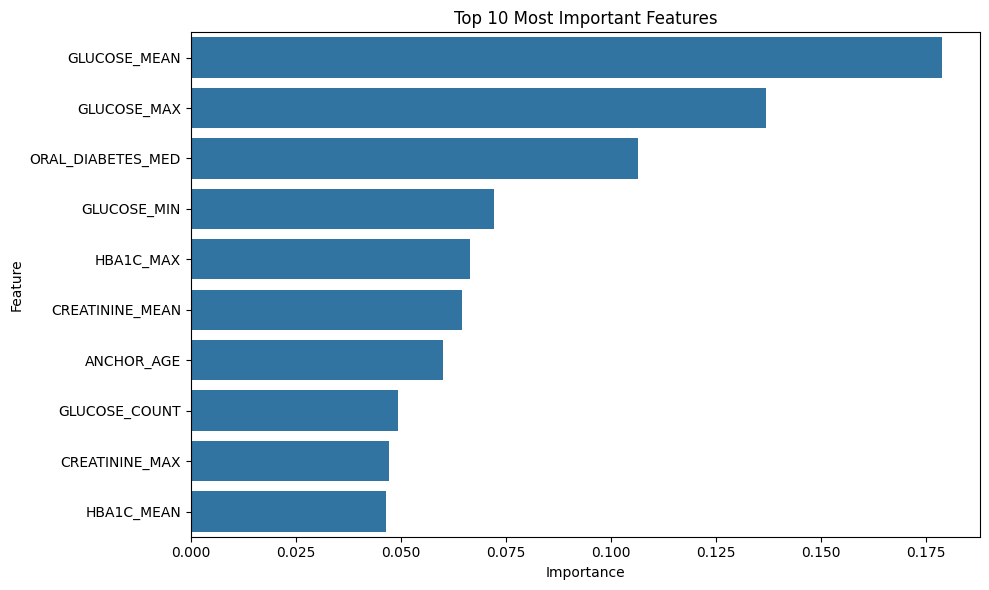


Top 10 most important features:
              Feature  Importance
4        GLUCOSE_MEAN    0.178965
5         GLUCOSE_MAX    0.137007
3   ORAL_DIABETES_MED    0.106570
6         GLUCOSE_MIN    0.072165
9           HBA1C_MAX    0.066582
12    CREATININE_MEAN    0.064529
1          ANCHOR_AGE    0.060151
7       GLUCOSE_COUNT    0.049301
13     CREATININE_MAX    0.047223
8          HBA1C_MEAN    0.046508

Comparing models with 5-fold cross-validation:
Logistic Regression: Mean ROC AUC = 0.9173 (±0.0048)
Random Forest: Mean ROC AUC = 0.9254 (±0.0058)
Gradient Boosting: Mean ROC AUC = 0.9303 (±0.0053)


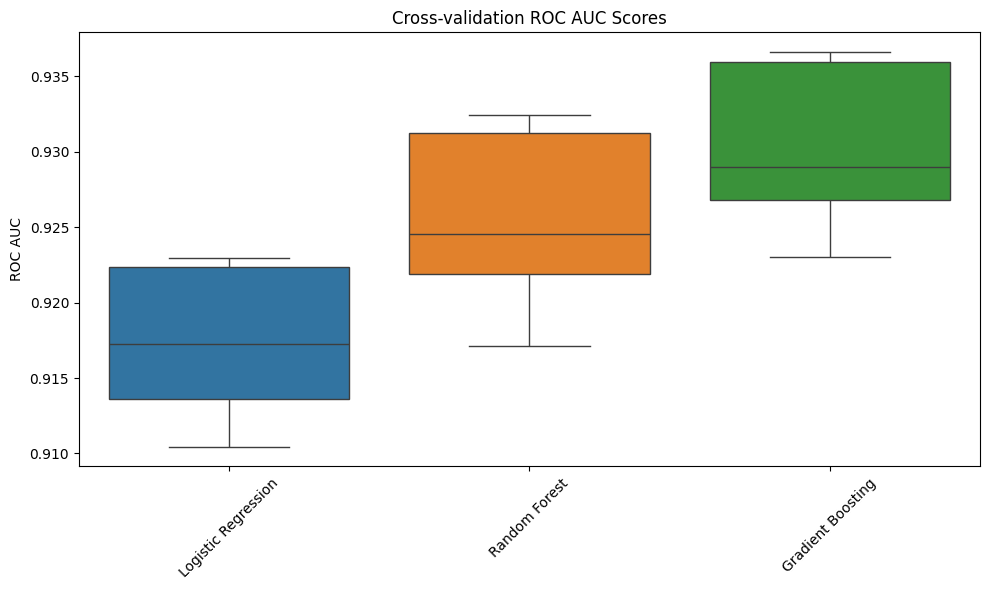


Best model based on cross-validation: Gradient Boosting

Performing hyperparameter tuning for Gradient Boosting...
Best parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100, 'classifier__subsample': 1.0}
Best cross-validation score: 0.9318

Evaluating final model on test set...

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      7240
           1       0.80      0.67      0.73      2064

    accuracy                           0.89      9304
   macro avg       0.85      0.81      0.83      9304
weighted avg       0.88      0.89      0.89      9304



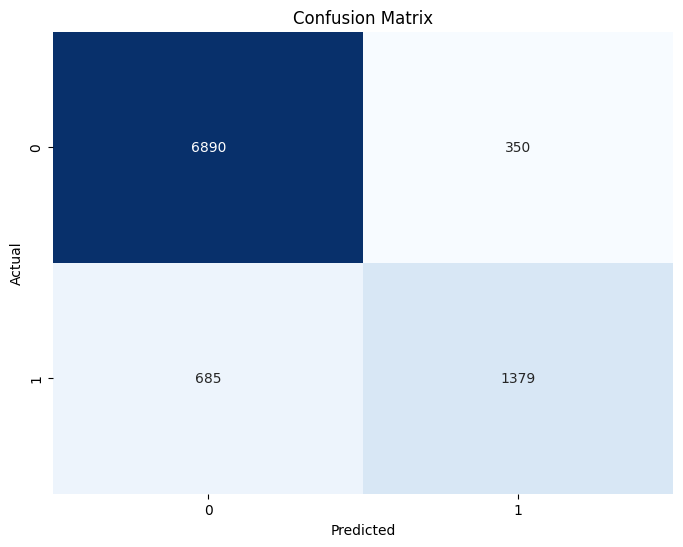

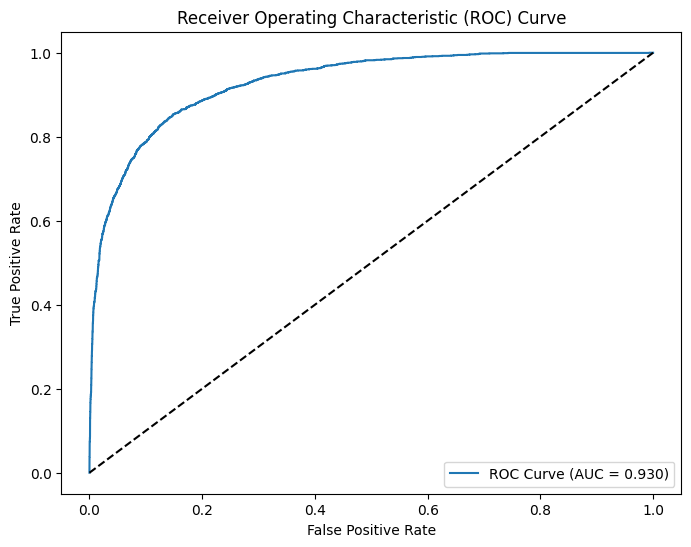

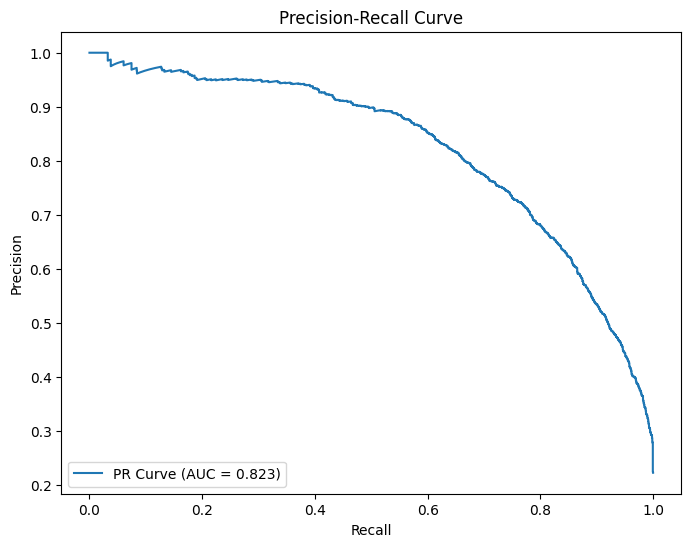

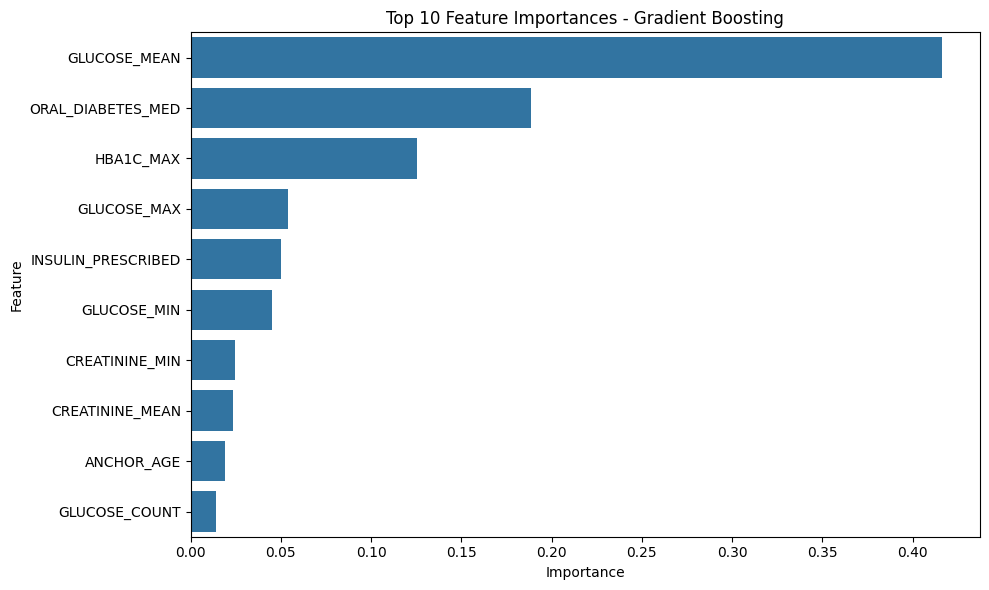


Top 10 features from the final model:
               Feature  Importance
4         GLUCOSE_MEAN    0.416511
3    ORAL_DIABETES_MED    0.188321
9            HBA1C_MAX    0.125149
5          GLUCOSE_MAX    0.053727
2   INSULIN_PRESCRIBED    0.049990
6          GLUCOSE_MIN    0.045220
14      CREATININE_MIN    0.024464
12     CREATININE_MEAN    0.023523
1           ANCHOR_AGE    0.019192
7        GLUCOSE_COUNT    0.014230

Model saved as 'diabetes_classifier_model.pkl'

Example prediction:
Patient's predicted probability of diabetes: 0.2522
Prediction: Non-diabetic


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.feature_selection import SelectFromModel
import warnings
warnings.filterwarnings('ignore')

# Load the preprocessed data
print("Loading preprocessed data...")
df = pd.read_csv('diabetes_classifier_data.csv')
print(f"Dataset shape: {df.shape}")

# Display basic information about the dataset
print("\nColumn information:")
print(df.columns.tolist())
print("\nClass distribution:")
print(df['HAS_DIABETES'].value_counts(normalize=True) * 100)

# Separate features and target
X = df.drop(['SUBJECT_ID', 'HAS_DIABETES'], axis=1)
y = df['HAS_DIABETES']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Feature importance analysis with a preliminary Random Forest
print("\nAnalyzing feature importance...")
feature_selector = RandomForestClassifier(n_estimators=100, random_state=42)
feature_selector.fit(X_train, y_train)

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_selector.feature_importances_
})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title('Top 10 Most Important Features')
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(feature_importance.head(10))

# Define models to evaluate
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Create a processing pipeline with scaling and optional feature selection
pipeline_steps = [
    ('scaler', StandardScaler()),
    ('classifier', None)  # Placeholder for the classifier
]

# Compare models using cross-validation
print("\nComparing models with 5-fold cross-validation:")
cv_results = {}

for name, model in models.items():
    pipeline = Pipeline(pipeline_steps)
    pipeline.steps[1] = ('classifier', model)
    
    # Perform cross-validation
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='roc_auc')
    cv_results[name] = scores
    print(f"{name}: Mean ROC AUC = {scores.mean():.4f} (±{scores.std():.4f})")

# Visualize cross-validation results
plt.figure(figsize=(10, 6))
cv_df = pd.DataFrame(cv_results)
sns.boxplot(data=cv_df)
plt.title('Cross-validation ROC AUC Scores')
plt.ylabel('ROC AUC')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Select the best model (based on the cross-validation results)
best_model_name = max(cv_results, key=lambda k: cv_results[k].mean())
print(f"\nBest model based on cross-validation: {best_model_name}")

# Hyperparameter tuning for the best model
print(f"\nPerforming hyperparameter tuning for {best_model_name}...")

if best_model_name == 'Logistic Regression':
    param_grid = {
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l1', 'l2', 'elasticnet', None],
        'classifier__solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
    }
elif best_model_name == 'Random Forest':
    param_grid = {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [None, 10, 20, 30],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    }
else:  # Gradient Boosting
    param_grid = {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__max_depth': [3, 4, 5],
        'classifier__min_samples_split': [2, 5],
        'classifier__subsample': [0.8, 1.0]
    }

# Create pipeline with the best model
pipeline = Pipeline(pipeline_steps)
pipeline.steps[1] = ('classifier', models[best_model_name])

# Use GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Get the best model
best_model = grid_search.best_estimator_

# Final evaluation on the test set
print("\nEvaluating final model on test set...")
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Classification metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Precision-Recall Curve
plt.figure(figsize=(8, 6))
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

# If we used Gradient Boosting or Random Forest, examine feature importance
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    feature_importances = best_model.named_steps['classifier'].feature_importances_
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': feature_importances
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
    plt.title(f'Top 10 Feature Importances - {best_model_name}')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 features from the final model:")
    print(importance_df.head(10))

# Save the model
import joblib
joblib.dump(best_model, 'diabetes_classifier_model.pkl')
print("\nModel saved as 'diabetes_classifier_model.pkl'")

# Create a simple prediction function
def predict_diabetes(patient_data):
    """
    Predict diabetes probability for a single patient.
    
    Parameters:
    patient_data (dict): Dictionary containing patient features
    
    Returns:
    float: Probability of diabetes
    """
    # Convert to DataFrame with the same columns as training data
    features = pd.DataFrame([patient_data])
    
    # Make sure all required columns are present
    for col in X.columns:
        if col not in features.columns:
            features[col] = 0
    
    # Keep only the columns used for training
    features = features[X.columns]
    
    # Make prediction
    probability = best_model.predict_proba(features)[0, 1]
    return probability

# Example of how to use the prediction function
example_patient = {
    'GENDER': 1,  # Male
    'ANCHOR_AGE': 65,
    'INSULIN_PRESCRIBED': 0,
    'ORAL_DIABETES_MED': 0,
    'GLUCOSE_MEAN': 130,
    'HBA1C_MEAN': 6.2
}

# Other columns will be filled with 0 by the function
print("\nExample prediction:")
diabetes_probability = predict_diabetes(example_patient)
print(f"Patient's predicted probability of diabetes: {diabetes_probability:.4f}")
print(f"Prediction: {'Diabetic' if diabetes_probability > 0.5 else 'Non-diabetic'}")

### UAE Hospital Diabetes Classification

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# Load the dataset
cleaned_visit_data = pd.read_csv('/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/Assignments/Assignment 6: MIMIC MLDL/archive/cleaned_visit_data.csv')

# Step 1: Improved Data Exploration
print("Dataset Information:")
print(f"Shape: {cleaned_visit_data.shape}")
print("\nFirst 5 rows:")
print(cleaned_visit_data.head())

print("\nUnique Values in Diagnosis:")
unique_diagnoses = cleaned_visit_data['Diagnosis'].unique()
print(unique_diagnoses)

print("\nTarget Variable Distribution:")
print(cleaned_visit_data['Diagnosis'].value_counts())
print(cleaned_visit_data['Diagnosis'].value_counts(normalize=True))

# Step 2: Enhanced Data Preparation
# Handle empty spaces and unexpected values
cleaned_visit_data['Diagnosis'] = cleaned_visit_data['Diagnosis'].str.strip()
cleaned_visit_data['Diagnosis'] = cleaned_visit_data['Diagnosis'].replace('', 'Unknown')

# Check for and handle any unexpected categories
expected_categories = ['Type 1 Diabetes', 'Type 2 Diabetes', 'Prediabetes', 
                       'Type 3 Diabetes', 'Gestational Diabetes', 'Unknown']
for val in cleaned_visit_data['Diagnosis'].unique():
    if val not in expected_categories:
        print(f"Found unexpected value: '{val}', replacing with 'Unknown'")
        cleaned_visit_data['Diagnosis'] = cleaned_visit_data['Diagnosis'].replace(val, 'Unknown')

# Extract temporal features from Visit_Date
cleaned_visit_data['Visit_Date'] = pd.to_datetime(cleaned_visit_data['Visit_Date'])
cleaned_visit_data['Visit_Day'] = cleaned_visit_data['Visit_Date'].dt.day
cleaned_visit_data['Visit_Month'] = cleaned_visit_data['Visit_Date'].dt.month
cleaned_visit_data['Visit_Year'] = cleaned_visit_data['Visit_Date'].dt.year
cleaned_visit_data['Visit_Weekday'] = cleaned_visit_data['Visit_Date'].dt.dayofweek
cleaned_visit_data['Visit_Quarter'] = cleaned_visit_data['Visit_Date'].dt.quarter
cleaned_visit_data['Is_Weekend'] = cleaned_visit_data['Visit_Weekday'].apply(lambda x: 1 if x >= 5 else 0)

# Calculate additional features
cleaned_visit_data['Total_Visit_Time'] = (
    cleaned_visit_data['Registration time'] + 
    cleaned_visit_data['Nursing time'] + 
    cleaned_visit_data['Laboratory time'] + 
    cleaned_visit_data['Consultation time'] + 
    cleaned_visit_data['Pharmacy time']
)

# Compute time ratios
for time_col in ['Registration time', 'Nursing time', 'Laboratory time', 'Consultation time', 'Pharmacy time']:
    cleaned_visit_data[f'{time_col}_Ratio'] = cleaned_visit_data[time_col] / cleaned_visit_data['Total_Visit_Time']

# Drop the original Visit_Date column
cleaned_visit_data.drop('Visit_Date', axis=1, inplace=True)

# Use Label Encoder for the target variable
label_encoder = LabelEncoder()
cleaned_visit_data['Diagnosis_Encoded'] = label_encoder.fit_transform(cleaned_visit_data['Diagnosis'])
print("\nEncoded Diagnosis Mapping:")
for i, diagnosis in enumerate(label_encoder.classes_):
    print(f"{i}: {diagnosis}")

# Define features and target
X = cleaned_visit_data.drop(['Diagnosis', 'Diagnosis_Encoded', 'Patient_ID'], axis=1)
y = cleaned_visit_data['Diagnosis_Encoded']

# Define column types
categorical_cols = ['Gender', 'Has_Insurance', 'Area']
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# Define preprocessing for numerical and categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Preprocess the data
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Check for class imbalance and print class distribution
print("\nClass distribution in training set:")
for cls in np.unique(y_train):
    count = np.sum(y_train == cls)
    print(f"Class {cls} ({label_encoder.inverse_transform([cls])[0]}): {count} samples ({count/len(y_train)*100:.2f}%)")

# Calculate class weights for handling imbalance
class_weights = {}
for cls in np.unique(y_train):
    class_weights[cls] = len(y_train) / (len(np.unique(y_train)) * np.sum(y_train == cls))

print("\nClass weights:")
for cls, weight in class_weights.items():
    print(f"Class {cls}: {weight:.4f}")

# Step 3: Try a simpler model first - Gradient Boosting
print("\n--- Training a Gradient Boosting model first ---")
gb_model = GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=5)
gb_model.fit(X_train_preprocessed, y_train)

# Evaluate the GB model
gb_pred = gb_model.predict(X_test_preprocessed)
gb_accuracy = accuracy_score(y_test, gb_pred)
print(f"Gradient Boosting Accuracy: {gb_accuracy:.4f}")

print("\nClassification Report (Gradient Boosting):")
print(classification_report(y_test, gb_pred, target_names=label_encoder.classes_))

# Step 4: Try a simpler neural network with better optimization
print("\n--- Training a simplified neural network ---")

# Create a simpler model
def create_simple_nn(input_shape, num_classes):
    model = Sequential([
        # Simpler architecture with fewer layers
        Dense(64, activation='relu', input_shape=(input_shape,)),
        BatchNormalization(),
        Dropout(0.2),
        
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        
        Dense(num_classes, activation='softmax')
    ])
    
    # Use a lower learning rate
    optimizer = Adam(learning_rate=0.001)
    
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',  # Use sparse version since we're not one-hot encoding
        metrics=['accuracy']
    )
    
    return model

# Get the input shape
input_shape = X_train_preprocessed.shape[1]
num_classes = len(np.unique(y_train))

# Create the model
nn_model = create_simple_nn(input_shape, num_classes)
nn_model.summary()

# Define improved callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

# Train the model with more patience and learning rate reduction
history = nn_model.fit(
    X_train_preprocessed, 
    y_train,  # No need to one-hot encode with sparse_categorical_crossentropy
    epochs=50,
    batch_size=64,  # Larger batch size
    validation_split=0.2,  # Use part of training data for validation
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights,
    verbose=1
)

# Evaluate the neural network
nn_pred = np.argmax(nn_model.predict(X_test_preprocessed), axis=1)
nn_accuracy = accuracy_score(y_test, nn_pred)
print(f"\nNeural Network Accuracy: {nn_accuracy:.4f}")

print("\nClassification Report (Neural Network):")
print(classification_report(y_test, nn_pred, target_names=label_encoder.classes_))

# Step 5: Try a Random Forest as well
print("\n--- Training a Random Forest model ---")
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10, n_jobs=-1)
rf_model.fit(X_train_preprocessed, y_train)

# Evaluate the Random Forest
rf_pred = rf_model.predict(X_test_preprocessed)
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, rf_pred, target_names=label_encoder.classes_))

# Step 6: Choose the best model based on accuracy
print("\n--- Model Comparison ---")
model_accuracies = {
    "Gradient Boosting": gb_accuracy,
    "Neural Network": nn_accuracy,
    "Random Forest": rf_accuracy
}

best_model_name = max(model_accuracies, key=model_accuracies.get)
best_model_accuracy = model_accuracies[best_model_name]
print(f"Best Model: {best_model_name} with accuracy {best_model_accuracy:.4f}")

# Visualization for the best model
plt.figure(figsize=(12, 8))
if best_model_name == "Gradient Boosting":
    best_preds = gb_pred
    best_model = gb_model
elif best_model_name == "Neural Network":
    best_preds = nn_pred
    best_model = nn_model
else:
    best_preds = rf_pred
    best_model = rf_model

# Plot confusion matrix for the best model
cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.savefig('best_model_confusion_matrix.png')
plt.close()

# Feature importance analysis (if applicable)
if best_model_name in ["Gradient Boosting", "Random Forest"]:
    # For tree-based models, we can directly use feature_importances_
    feature_names = numeric_cols + [f"{col}_{category}" for col in categorical_cols 
                                 for category in preprocessor.transformers_[1][1].categories_[categorical_cols.index(col)]]
    
    # Make sure feature_names matches the feature count
    if len(feature_names) == best_model.feature_importances_.shape[0]:
        feature_importance = {feature_names[i]: best_model.feature_importances_[i] for i in range(len(feature_names))}
        sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)
        
        # Plot top 20 features
        plt.figure(figsize=(12, 8))
        features, importances = zip(*sorted_features[:20])
        plt.barh(features, importances)
        plt.xlabel('Feature Importance')
        plt.title(f'Top 20 Features - {best_model_name}')
        plt.tight_layout()
        plt.savefig('feature_importance.png')
        plt.close()
        
        print("\nTop 10 most important features:")
        for feature, importance in sorted_features[:10]:
            print(f"{feature}: {importance:.4f}")
    else:
        print("\nWarning: Feature names count doesn't match feature importance shape.")
        print(f"Feature names count: {len(feature_names)}")
        print(f"Feature importance shape: {best_model.feature_importances_.shape[0]}")

print("\nModels Training and Evaluation Completed!")

Dataset Information:
Shape: (504925, 13)

First 5 rows:
   Visit_Date  Patient_ID  Age  Gender        Diagnosis Has_Insurance  \
0  2019-01-01        4174   28    Male  Type 1 Diabetes           Yes   
1  2019-01-01        4507   62  Female  Type 2 Diabetes           Yes   
2  2019-01-01        1860   47    Male      Prediabetes           Yes   
3  2019-01-01        2294   10  Female  Type 2 Diabetes           Yes   
4  2019-01-01        2130   66    Male  Type 2 Diabetes           Yes   

             Area  Total_Cost  Registration time  Nursing time  \
0  Downtown Dubai  711.975905               21.6          21.1   
1  Downtown Dubai  507.680147               13.0          50.9   
2  Downtown Dubai  317.582770               27.3          20.9   
3  Downtown Dubai  484.387822               19.2          30.8   
4  Downtown Dubai  118.649105               13.3          29.1   

   Laboratory time  Consultation time  Pharmacy time  
0             29.6               25.8           28.2 

/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/ai_healthcare_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,838 (18.90 KB)

...

 Non-trainable params: 192 (768.00 B)

Epoch 1/50
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.1662 - loss: 1.7070 - val_accuracy: 0.2403 - val_loss: 1.6864 - learning_rate: 0.0010
Epoch 2/50
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.1773 - loss: 1.5890 - val_accuracy: 0.3371 - val_loss: 1.6597 - learning_rate: 0.0010
Epoch 3/50
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.1920 - loss: 1.5775 - val_accuracy: 0.0887 - val_loss: 1.6754 - learning_rate: 0.0010
Epoch 4/50
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.1485 - loss: 1.5854 - val_accuracy: 0.2937 - val_loss: 1.6576 - learning_rate: 0.0010
Epoch 5/50
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.1717 - loss: 1.5826 - val_accuracy: 0.2896 - val_loss: 1.6685 - learning_rate: 0.0010
Epoch 6/50
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.2157 - loss: 1.5729 - val_accuracy: 0.0648 - val_loss: 1.6828 - learning_rate: 0.0010
Epoch 7/50
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.1624 - l

/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/ai_healthcare_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/ai_healthcare_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mastermind63/Documents/UT Austin/Spring 2025/AI in Healthcare/ai_healthcare_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being s


Top 10 most important features:
Total_Visit_Time: 0.1779
Registration time: 0.1464
Laboratory time: 0.1350
Pharmacy time: 0.1300
Nursing time: 0.1211
Total_Cost: 0.1152
Consultation time: 0.1037
Registration time_Ratio: 0.0086
Consultation time_Ratio: 0.0083
Pharmacy time_Ratio: 0.0082

Models Training and Evaluation Completed!


<Figure size 1200x800 with 0 Axes>